In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt

from src.operators import MeasurementOperator
from src.admm import admm_solve
from src.metrics import relative_error, psnr, ssim, print_metrics
from config import (SHEPP_LOGAN_PATH, CAMERA_PATH, IMAGE_SIZE,
                    RANDOM_SEED, RHO, MAX_ITER, TOL, N_MEASUREMENTS)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['image.cmap'] = 'gray'

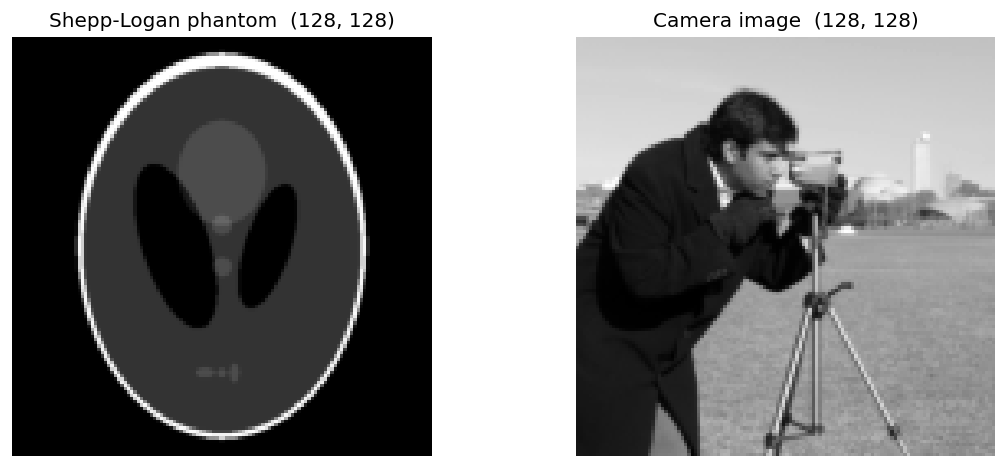

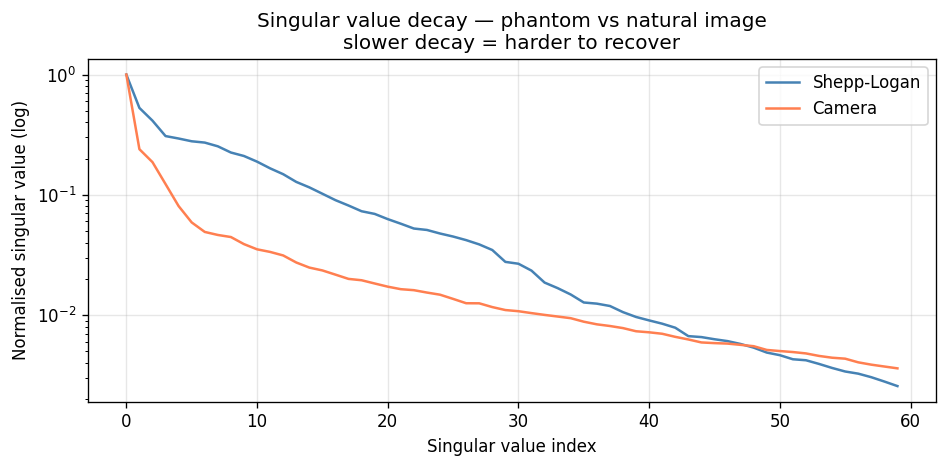

In [ ]:
X_phantom = np.load(SHEPP_LOGAN_PATH)
X_camera  = np.load(CAMERA_PATH)

assert X_phantom.min() >= 0 and X_phantom.max() <= 1
assert X_camera.min()  >= 0 and X_camera.max()  <= 1

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(X_phantom)
axes[0].set_title(f"Shepp-Logan phantom  {X_phantom.shape}")
axes[0].axis('off')
axes[1].imshow(X_camera)
axes[1].set_title(f"Camera image  {X_camera.shape}")
axes[1].axis('off')
plt.tight_layout()
plt.show()

#Compare singular value decay
sigma_p = np.linalg.svd(X_phantom, compute_uv=False)
sigma_c = np.linalg.svd(X_camera,  compute_uv=False)

#Normalise to compare decay shape fairly
sigma_p_norm = sigma_p / sigma_p[0]
sigma_c_norm = sigma_c / sigma_c[0]

plt.figure(figsize=(8, 4))
plt.semilogy(sigma_p_norm[:60], color='steelblue',
             linewidth=1.5, label='Shepp-Logan')
plt.semilogy(sigma_c_norm[:60], color='coral',
             linewidth=1.5, label='Camera')
plt.xlabel("Singular value index")
plt.ylabel("Normalised singular value (log)")
plt.title("Singular value decay — phantom vs natural image\n"
          "slower decay = harder to recover")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [3]:
#Testing generalisation

results = {}

for name, X_true in [("Shepp-Logan", X_phantom), ("Camera", X_camera)]:
    op  = MeasurementOperator(n=IMAGE_SIZE, m=N_MEASUREMENTS, seed=RANDOM_SEED)
    y   = op.measure(X_true)
    res = admm_solve(op, y, rho=RHO, max_iter=MAX_ITER,
                     tol=TOL, X_true=X_true, verbose=False)
    results[name] = (X_true, res)
    print(f"\n{name}")
    print("-" * 30)
    print_metrics(res.X, X_true)
    print(f"Converged  : {res.converged}  ({res.n_iters} iters)")


Shepp-Logan
------------------------------
Relative error : 0.362403
PSNR: 21.99 dB
SSIM: 0.338579
Converged  : True  (179 iters)

Camera
------------------------------
Relative error : 0.133419
PSNR: 22.12 dB
SSIM: 0.427595
Converged  : True  (204 iters)


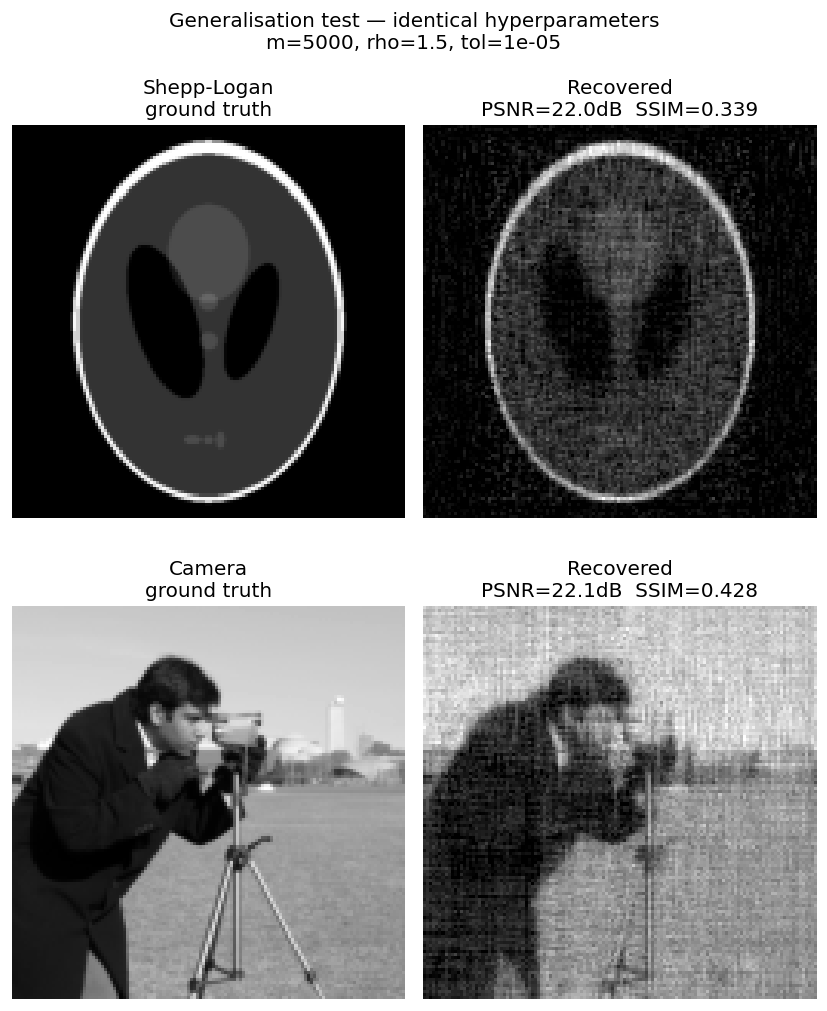

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(7, 9))

for row, (name, (X_true, res)) in enumerate(results.items()):
    axes[row, 0].imshow(X_true)
    axes[row, 0].set_title(f"{name}\nground truth")
    axes[row, 0].axis('off')

    axes[row, 1].imshow(np.clip(res.X, 0, 1))
    rel = relative_error(res.X, X_true)
    p   = psnr(res.X, X_true)
    s   = ssim(res.X, X_true)
    axes[row, 1].set_title(f"Recovered\nPSNR={p:.1f}dB  SSIM={s:.3f}")
    axes[row, 1].axis('off')

    #axes[row, 2].imshow(np.abs(res.X - X_true), cmap='hot')
    #axes[row, 2].set_title(f"Absolute error\nrel_err={rel:.4f}")
    #axes[row, 2].axis('off')

plt.suptitle(f"Generalisation test — identical hyperparameters\n"
             f"m={N_MEASUREMENTS}, rho={RHO}, tol={TOL}", fontsize=12)
plt.tight_layout()
plt.show()

In [5]:
#Metrics comparison

print(f"{'Metric':<20} {'Shepp-Logan':>15} {'Camera':>15} {'Gap':>10}")
print("-" * 62)

X_p, res_p = results["Shepp-Logan"]
X_c, res_c = results["Camera"]

rel_p = relative_error(res_p.X, X_p)
rel_c = relative_error(res_c.X, X_c)
psnr_p = psnr(res_p.X, X_p)
psnr_c = psnr(res_c.X, X_c)
ssim_p = ssim(res_p.X, X_p)
ssim_c = ssim(res_c.X, X_c)

print(f"{'Relative error':<20} {rel_p:>15.4f} {rel_c:>15.4f} {rel_c-rel_p:>+10.4f}")
print(f"{'PSNR (dB)':<20} {psnr_p:>15.2f} {psnr_c:>15.2f} {psnr_c-psnr_p:>+10.2f}")
print(f"{'SSIM':<20} {ssim_p:>15.4f} {ssim_c:>15.4f} {ssim_c-ssim_p:>+10.4f}")
print(f"{'Converged':<20} {str(res_p.converged):>15} {str(res_c.converged):>15}")
print(f"{'Iterations':<20} {res_p.n_iters:>15} {res_c.n_iters:>15}")

print(f"\nConclusion:")
if psnr_c < psnr_p - 3:
    print(f"Camera image is harder — PSNR gap of {psnr_p-psnr_c:.1f}dB is explained")
    print(f"by slower singular value decay in natural images.")
else:
    print(f"Both images recover similarly — nuclear norm prior")
    print(f"generalises well at this sampling ratio.")

Metric                   Shepp-Logan          Camera        Gap
--------------------------------------------------------------
Relative error                0.3624          0.1334    -0.2290
PSNR (dB)                      21.99           22.12      +0.14
SSIM                          0.3386          0.4276    +0.0890
Converged                       True            True
Iterations                       179             204

Conclusion:
Both images recover similarly — nuclear norm prior
generalises well at this sampling ratio.
